In [ ]:
# ========================
# 1️⃣ ENVIRONMENT CHECK
# ========================
import torch
import random
import numpy as np
from pathlib import Path
from ultralytics import YOLO

# Set seed for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Check CUDA availability
print("PyTorch CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Using CPU — training will be slow")

# ==========================
# 2️⃣ USER CONFIGURATION
# ==========================
# Dataset YAML file
data_yaml = r"E:\Coins\Coin Classification.v7i.yolov8\data.yaml"

# Folder to save retraining results
output_project_dir = r"E:\Coins\Coin Classification.v7i.yolov8"
run_name = "yolov8_coin_model_retrain"

# Path to your last checkpoint
checkpoint_path = r"E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model3\weights\last.pt"

# Training parameters
epochs = 500  # additional training epochs
imgsz = 640
batch = 16
patience = 10  # Early stopping

# ==========================
# 3️⃣ LOAD MODEL FROM LAST CHECKPOINT
# ==========================
model = YOLO(checkpoint_path)  # Load from last.pt
Path(output_project_dir).mkdir(parents=True, exist_ok=True)

# ==========================
# 4️⃣ CONTINUE TRAINING
# ==========================
model.train(
    data=data_yaml,
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    patience=patience,
    project=output_project_dir,
    name=run_name,
    device=0 if torch.cuda.is_available() else "cpu",
    save=True,     # Saves last.pt and best.pt automatically
    val=True,
    verbose=True,
    optimizer="AdamW",
    lr0=0.0015,  # Keep the same LR or lower if fine-tuning
    lrf=0.01,
    weight_decay=0.0005,
    label_smoothing=0.05,
    save_period=1  # Save checkpoint every epoch
)

# ==========================
# 5️⃣ VALIDATE RETRAINED MODEL
# ==========================
best_model_path = Path(output_project_dir) / run_name / "weights" / "best.pt"
print("✅ Best retrained model saved at:", best_model_path)

best_model = YOLO(str(best_model_path))
metrics = best_model.val()
print("mAP50-95:", metrics.box.map, "mAP50:", metrics.box.map50)


PyTorch CUDA available: True
GPU: NVIDIA GeForce GTX 1660 SUPER
New https://pypi.org/project/ultralytics/8.3.178 available  Update with 'pip install -U ultralytics'
WARNING 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.124  Python-3.10.16 torch-2.5.1 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
engine\trainer: task=detect, mode=train, model=E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model3\weights\last.pt, data=E:\Coins\Coin Classification.v7i.yolov8\data.yaml, epochs=500, time=None, patience=10, batch=16, imgsz=640, save=True, save_period=1, cache=False, device=0, workers=8, project=E:\Coins\Coin Classification.v7i.yolov8, name=yolov8_coin_model_retrain, exist_ok=False, pretrained=True, optimizer=AdamW, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, 

train: Scanning E:\Coins\Coin Classification.v7i.yolov8\train\labels.cache... 3252 images, 9 backgrounds, 0 corrupt: 10
C:\Users\silva\anaconda3\envs\coin_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access  (ping: 0.10.0 ms, read: 2.31.4 MB/s, size: 18.2 KB)


val: Scanning E:\Coins\Coin Classification.v7i.yolov8\valid\labels.cache... 302 images, 0 backgrounds, 0 corrupt: 100%|


Plotting labels to E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model_retrain\labels.jpg... 
optimizer: AdamW(lr=0.0015, momentum=0.937) with parameter groups 77 weight(decay=0.0), 84 weight(decay=0.0005), 83 bias(decay=0.0)
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model_retrain
Starting training for 500 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      1/500      2.94G     0.5398      0.487     0.9604         48        640: 100%|██████████| 204/204 [42:13<00:00, 1
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [01:14

                   all        302       1393      0.942      0.941      0.976      0.916



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      2/500      10.4G     0.5447     0.5066      1.076         74        640:   0%|          | 1/204 [00:15<52:48, 15.

Ultralytics 8.3.124  Python-3.10.16 torch-2.5.1 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
Model summary (fused): 92 layers, 25,850,182 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1.20.3 MB/s, size: 16.3 KB)


val: Scanning E:\Coins\Coin Classification.v7i.yolov8\test\labels... 151 images, 0 backgrounds, 0 corrupt: 100%|███████

val: New cache created: E:\Coins\Coin Classification.v7i.yolov8\test\labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 10/10 [00:04


                   all        151        749      0.942       0.93       0.96      0.894
 Chinese One Yuan Coin         20         21      0.926      0.952      0.971      0.901
Japanese Fifty Yen Coin         26         35          1      0.934      0.975      0.922
Japanese Five Hundred Coin         20         21      0.892      0.905      0.948      0.894
Japanese Five Yen Coin         31         50      0.965          1      0.976      0.906
Japanese One Hundred Yen Coin         22         52      0.994      0.962      0.981      0.919
 Japanese One Yen Coin         26         44      0.978      0.996      0.993      0.894
 Japanese Ten Yen Coin         34        103      0.995          1      0.995      0.925
 Korean Fifty Won Coin         26         33          1      0.923      0.942      0.887
Korean Five Hundred Won Coin         22         28      0.877      0.929      0.943       0.86
Korean One Hundred Won Coin         21         45      0.889      0.956      0.961      0.90

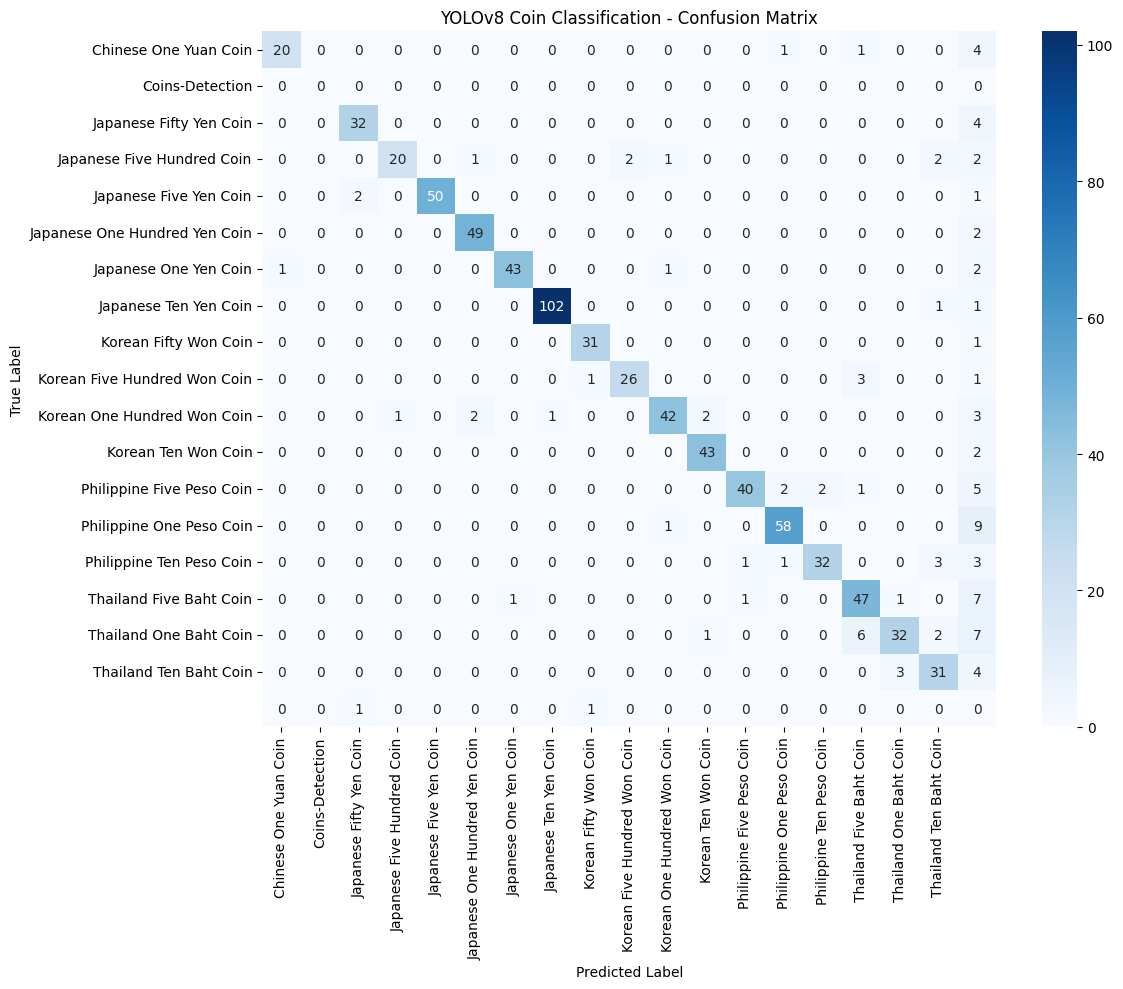

In [2]:
# ========================
# 1️⃣ IMPORTS
# ========================
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from pathlib import Path

# ========================
# 2️⃣ CONFIGURATION
# ========================
model_path = r"E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model3\weights\best.pt"
data_yaml = r"E:\Coins\Coin Classification.v7i.yolov8\data.yaml"

# Load trained model
model = YOLO(model_path)

# ========================
# 3️⃣ VALIDATE MODEL
# ========================
# Run validation on the test set
metrics = model.val(data=data_yaml, split="test", save_json=True, verbose=True)

# metrics.names contains class names
class_names = list(metrics.names.values())

# ========================
# 4️⃣ PER-CLASS ACCURACY
# ========================
# metrics.box.mp contains mAP per class
print("\n📊 Per-Class Accuracy (mAP50-95):")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {metrics.box.maps[i]:.4f}")

# ========================
# 5️⃣ CONFUSION MATRIX
# ========================
# YOLO stores confusion matrix in metrics.confusion_matrix.matrix
conf_matrix = metrics.confusion_matrix.matrix  # shape: [num_classes, num_classes]

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("YOLOv8 Coin Classification - Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [5]:
# ========================
# 1️⃣ IMPORTS
# ========================
import torch
from ultralytics import YOLO
from pathlib import Path

# ========================
# 2️⃣ CONFIGURATION
# ========================
model_path = r"E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model3\weights\best.pt"
test_image = r"E:\Downloads\486365813_660833043015207_4559032498092915957_n.jpg"

# Load model
model = YOLO(model_path)

# ========================
# 3️⃣ RUN INFERENCE
# ========================
results = model.predict(
    source=test_image,
    conf=0.25,        # confidence threshold
    save=True,        # save the image with bounding boxes
    show=True         # display in notebook window
)

# ========================
# 4️⃣ OUTPUT LOCATION
# ========================
# YOLO saves results in runs/detect/predictX
output_dir = Path(results[0].save_dir)
print(f"✅ Output saved in: {output_dir}")


WARNING Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'


image 1/1 E:\Downloads\486365813_660833043015207_4559032498092915957_n.jpg: 640x480 1 Japanese Fifty Yen Coin, 1 Japanese One Hundred Yen Coin, 2 Japanese One Yen Coins, 1 Japanese Ten Yen Coin, 2 Korean One Hundred Won Coins, 1 Thailand One Baht Coin, 24.1ms
Speed: 2.5ms preprocess, 24.1ms inference, 2.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs\detect\predict
✅ Output saved in: runs\detect\predict


In [3]:
import os
from pathlib import Path
import cv2
from ultralytics import YOLO

# ==============================
# CONFIGURATION
# ==============================
model_path = r"E:\Coins\Coin Classification.v7i.yolov8\yolov8_coin_model3\weights\best.pt"
source_images_dir = r"E:\Coins\Coin Classification.v7i.yolov8\valid\images"
output_dir = r"E:\Coins\New coins\valid"

# Class names from your dataset.yaml
class_names = [
    'Chinese One Yuan Coin', 'Coins-Detection', 'Japanese Fifty Yen Coin', 
    'Japanese Five Hundred Coin', 'Japanese Five Yen Coin', 
    'Japanese One Hundred Yen Coin', 'Japanese One Yen Coin', 
    'Japanese Ten Yen Coin', 'Korean Fifty Won Coin', 
    'Korean Five Hundred Won Coin', 'Korean One Hundred Won Coin', 
    'Korean Ten Won Coin', 'Philippine Five Peso Coin', 
    'Philippine One Peso Coin', 'Philippine Ten Peso Coin', 
    'Thailand Five Baht Coin', 'Thailand One Baht Coin', 'Thailand Ten Baht Coin'
]

# ==============================
# LOAD MODEL
# ==============================
model = YOLO(model_path)

# Ensure output directory exists
Path(output_dir).mkdir(parents=True, exist_ok=True)

# ==============================
# PROCESS IMAGES
# ==============================
image_paths = list(Path(source_images_dir).glob("*.*"))

for img_path in image_paths:
    results = model.predict(source=str(img_path), conf=0.25, verbose=False)

    img = cv2.imread(str(img_path))

    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                cls_id = int(box.cls[0])
                cls_name = class_names[cls_id]

                # Get coordinates
                x1, y1, x2, y2 = map(int, box.xyxy[0])

                # Crop the coin
                crop_img = img[y1:y2, x1:x2]

                # Ensure class folder exists
                save_folder = Path(output_dir) / cls_name
                save_folder.mkdir(parents=True, exist_ok=True)

                # Save cropped image
                save_path = save_folder / f"{img_path.stem}_{cls_name}_{x1}_{y1}.jpg"
                cv2.imwrite(str(save_path), crop_img)

print("✅ Cropped and sorted coins saved in:", output_dir)


✅ Cropped and sorted coins saved in: E:\Coins\New coins\valid


Confusion matrix saved to: E:\Downloads\matrix\Article 1 Confusion Matrix.png


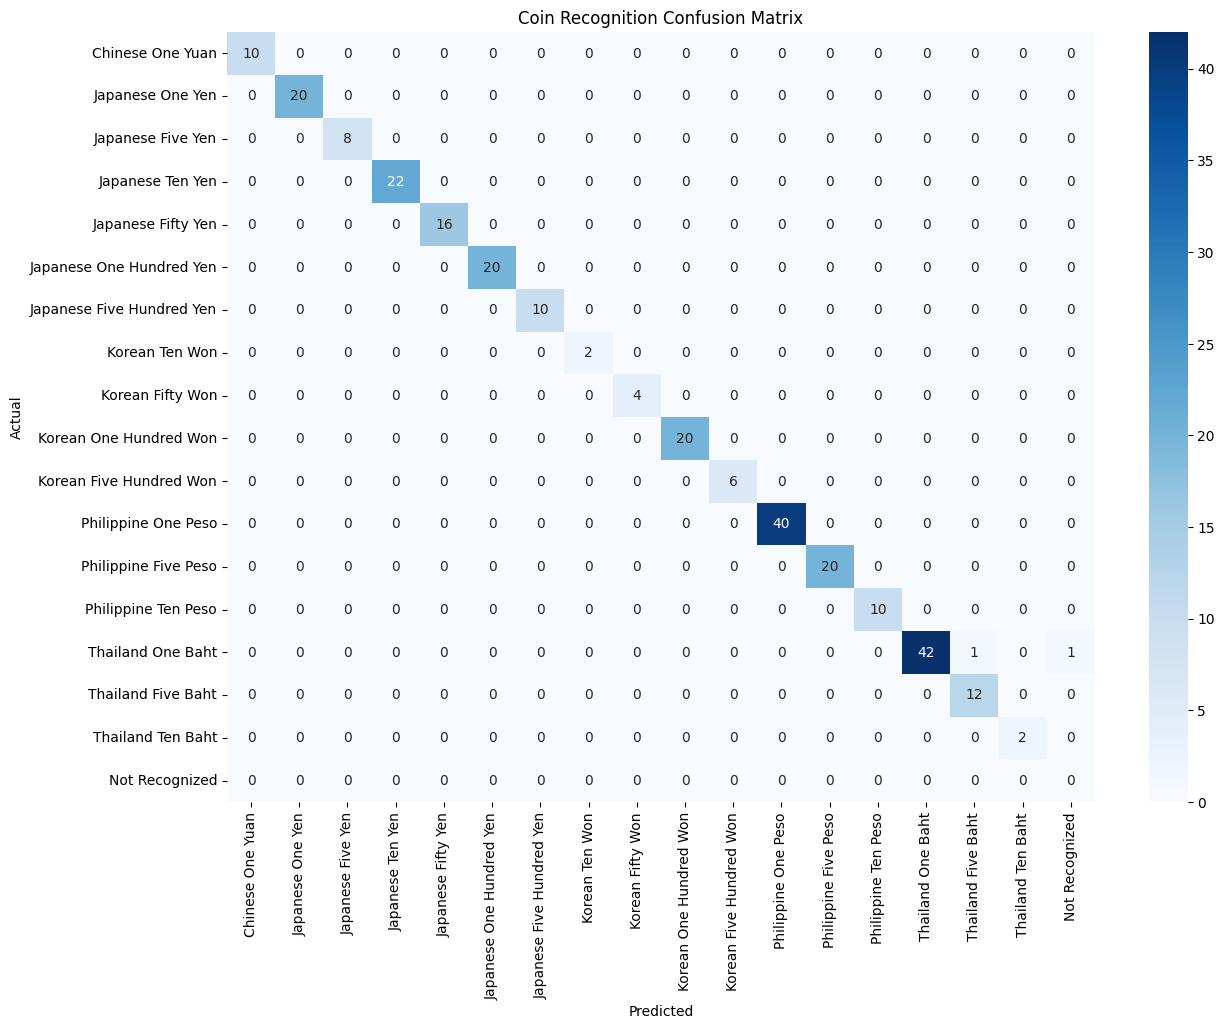

In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Define classes (including "Not Recognized")
classes = [
    "Chinese One Yuan",
    "Japanese One Yen",
    "Japanese Five Yen",
    "Japanese Ten Yen",
    "Japanese Fifty Yen",
    "Japanese One Hundred Yen",
    "Japanese Five Hundred Yen",
    "Korean Ten Won",
    "Korean Fifty Won",
    "Korean One Hundred Won",
    "Korean Five Hundred Won",
    "Philippine One Peso",
    "Philippine Five Peso",
    "Philippine Ten Peso",
    "Thailand One Baht",
    "Thailand Five Baht",
    "Thailand Ten Baht",
    "Not Recognized"
]

y_true = []
y_pred = []

def add_results(true_label, correct, misclassifications):
    y_true.extend([true_label] * correct)
    y_pred.extend([true_label] * correct)
    for pred_label, count in misclassifications:
        y_true.extend([true_label] * count)
        y_pred.extend([pred_label] * count)

# Add all results
add_results("Chinese One Yuan", 10, [])
add_results("Japanese One Yen", 20, [])
add_results("Japanese Five Yen", 8, [])
add_results("Japanese Ten Yen", 22, [])
add_results("Japanese Fifty Yen", 16, [])
add_results("Japanese One Hundred Yen", 20, [])
add_results("Japanese Five Hundred Yen", 10, [])
add_results("Korean Ten Won", 2, [])
add_results("Korean Fifty Won", 4, [])
add_results("Korean One Hundred Won", 20, [])
add_results("Korean Five Hundred Won", 6, [])
add_results("Philippine One Peso", 40, [])
add_results("Philippine Five Peso", 20, [])
add_results("Philippine Ten Peso", 10, [])
add_results("Thailand One Baht", 42, [("Thailand Five Baht", 1), ("Not Recognized", 1)])
add_results("Thailand Five Baht", 12, [])
add_results("Thailand Ten Baht", 2, [])

# Build confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)
cm_df = pd.DataFrame(cm, index=classes, columns=classes)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Coin Recognition Confusion Matrix')

# Save high-resolution image
output_dir = r"E:\Downloads\matrix"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, "Article 1 Confusion Matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Confusion matrix saved to: {save_path}")

plt.show()


In [1]:
from ultralytics import YOLO

# Load your old trained model (18 classes)
model = YOLO("E:/Coins/Coin Classification.v8i.yolov8/best.pt")

# Train on new dataset (20 classes)
model.train(
    data="E:/Coins/Coin Classification.v8i.yolov8/data.yaml",
    epochs=80,
    imgsz=640,
    batch=8,
    lr0=0.001,
    patience=20,
    device=0
)

Ultralytics 8.4.18  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=E:/Coins/Coin Classification.v8i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=E:/Coins/Coin Classification.v8i.yolov8/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train19, nbs=64, nms=False, opset=None, opt

KeyboardInterrupt: 

In [1]:
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata (27 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata (6.3 kB)
  Using cached https://download.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-win_amd64.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 108.8 MB/s eta 0:00:26
    --------------------------------------- 0.0/2.8 GB 99.9 MB/s eta 0:00:28
    --------------------------------------- 0.1/2.8 GB 87.8 MB/s eta 0:00:32
    --------------------------------------- 0.1/2.8 GB 81.6 MB/s eta 0:00:34
   - -------------------------------------- 0.1/2.8 GB 77.9 MB/s eta 0:00:36
   - -------------------------------------- 0.1/2.8 GB 75.9 MB/s eta 0:00:36
   - -------------------------------------- 

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1660 SUPER


In [5]:
from ultralytics import YOLO

model = YOLO("C:/Users/silva/runs/detect/train19/weights/best.pt")

metrics = model.val(
    data="E:/Coins/Coin Classification.v8i.yolov8/data.yaml",
    split="val",
    workers=0,   # 👈 THIS is the fix
    plots=True
)

Ultralytics 8.4.18  Python-3.12.7 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1660 SUPER, 6144MiB)
Model summary (fused): 93 layers, 25,851,340 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 59.865.8 MB/s, size: 37.3 KB)
val: Scanning E:\Coins\Coin Classification.v8i.yolov8\valid\labels.cache... 362 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 362/362  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 1.9s/it 43.4s1.9ss
                   all        362       1693      0.961      0.959      0.978       0.92
 Chinese One Yuan Coin         49         66      0.985      0.981      0.993      0.945
Japanese Fifty Yen Coin         66        110      0.981       0.95      0.983      0.923
Japanese Five Hundred Coin         68         93      0.922      0.892      0.972      0.912
Japanese Five Yen Coin         49         69      0.929      0.986      0.948        0.9
Japanese On

In [16]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# ==== CHANGE IMAGE PATH ONLY ====
model_path = r"C:\Users\silva\runs\detect\train19\weights\best.pt"
image_path = r"E:\Coins\Combined Coins Korean 1 and 5\combined_image_19.jpg"
save_dir = r"C:\Users\silva\runs\detect\train19\weights"
# =================================

# Load model
model = YOLO(model_path)

# Run prediction
results = model(image_path, conf=0.4)

# Get annotated image (with boxes + labels + confidence)
annotated_img = results[0].plot()

# Convert for correct saving
annotated_img_bgr = cv2.cvtColor(annotated_img, cv2.COLOR_RGB2BGR)

# Create filename
output_path = os.path.join(save_dir, "prediction_output.jpg")

# Save image
cv2.imwrite(output_path, annotated_img_bgr)

print(f"Saved to: {output_path}")

# Show image
plt.figure(figsize=(10,10))
plt.imshow(annotated_img)
plt.axis("off")
plt.show()


image 1/1 E:\Coins\Combined Coins Korean 1 and 5\combined_image_19.jpg: 640x640 1 Chinese One Yuan Coin, 5 Korean Five Won Coins, 3 Korean One Won Coins, 145.0ms
Speed: 4.4ms preprocess, 145.0ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Saved to: C:\Users\silva\runs\detect\train19\weights\prediction_output.jpg


<Figure size 1000x1000 with 1 Axes>